In [36]:
# Primeira célula do notebook - Definição de todas as URLs
import cv2 as cv 
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib
import ssl
from glob import glob
from urllib.request import urlopen
import time

ssl._create_default_https_context = ssl._create_unverified_context

BASE_URL = "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task03"

# As url's organizadas por questões no gh
URLS = {
    "q1": {
        "images": [f"{BASE_URL}/q1/{i}.{'jpeg' if i <= 2 else 'jpg'}" for i in range(1, 11)]
    },
    
    "q2": {
        "images": [f"{BASE_URL}/q2/{i}.jpg" for i in range(1, 19)]
    },
    
    "q3": {
        "soccer": f"{BASE_URL}/q3/soccer.jpg",
        "perimetro": f"{BASE_URL}/q3/perimetro.png"
    },
    
    "q4": {
        "frente": f"{BASE_URL}/q4/frente.jpg",
        "esq": f"{BASE_URL}/q4/esq.jpg",
        "dir": f"{BASE_URL}/q4/dir.jpg"
        # "tabuleiro": f"{BASE_URL}/q4/xadrez-tabuleiro.jpg"
    }
}

# Função de carregamento de imagem
def load_image_from_url(url):
    with urllib.request.urlopen(url) as response:
        img_array = np.asarray(bytearray(response.read()), dtype=np.uint8)
        return cv.imdecode(img_array, cv.IMREAD_COLOR)

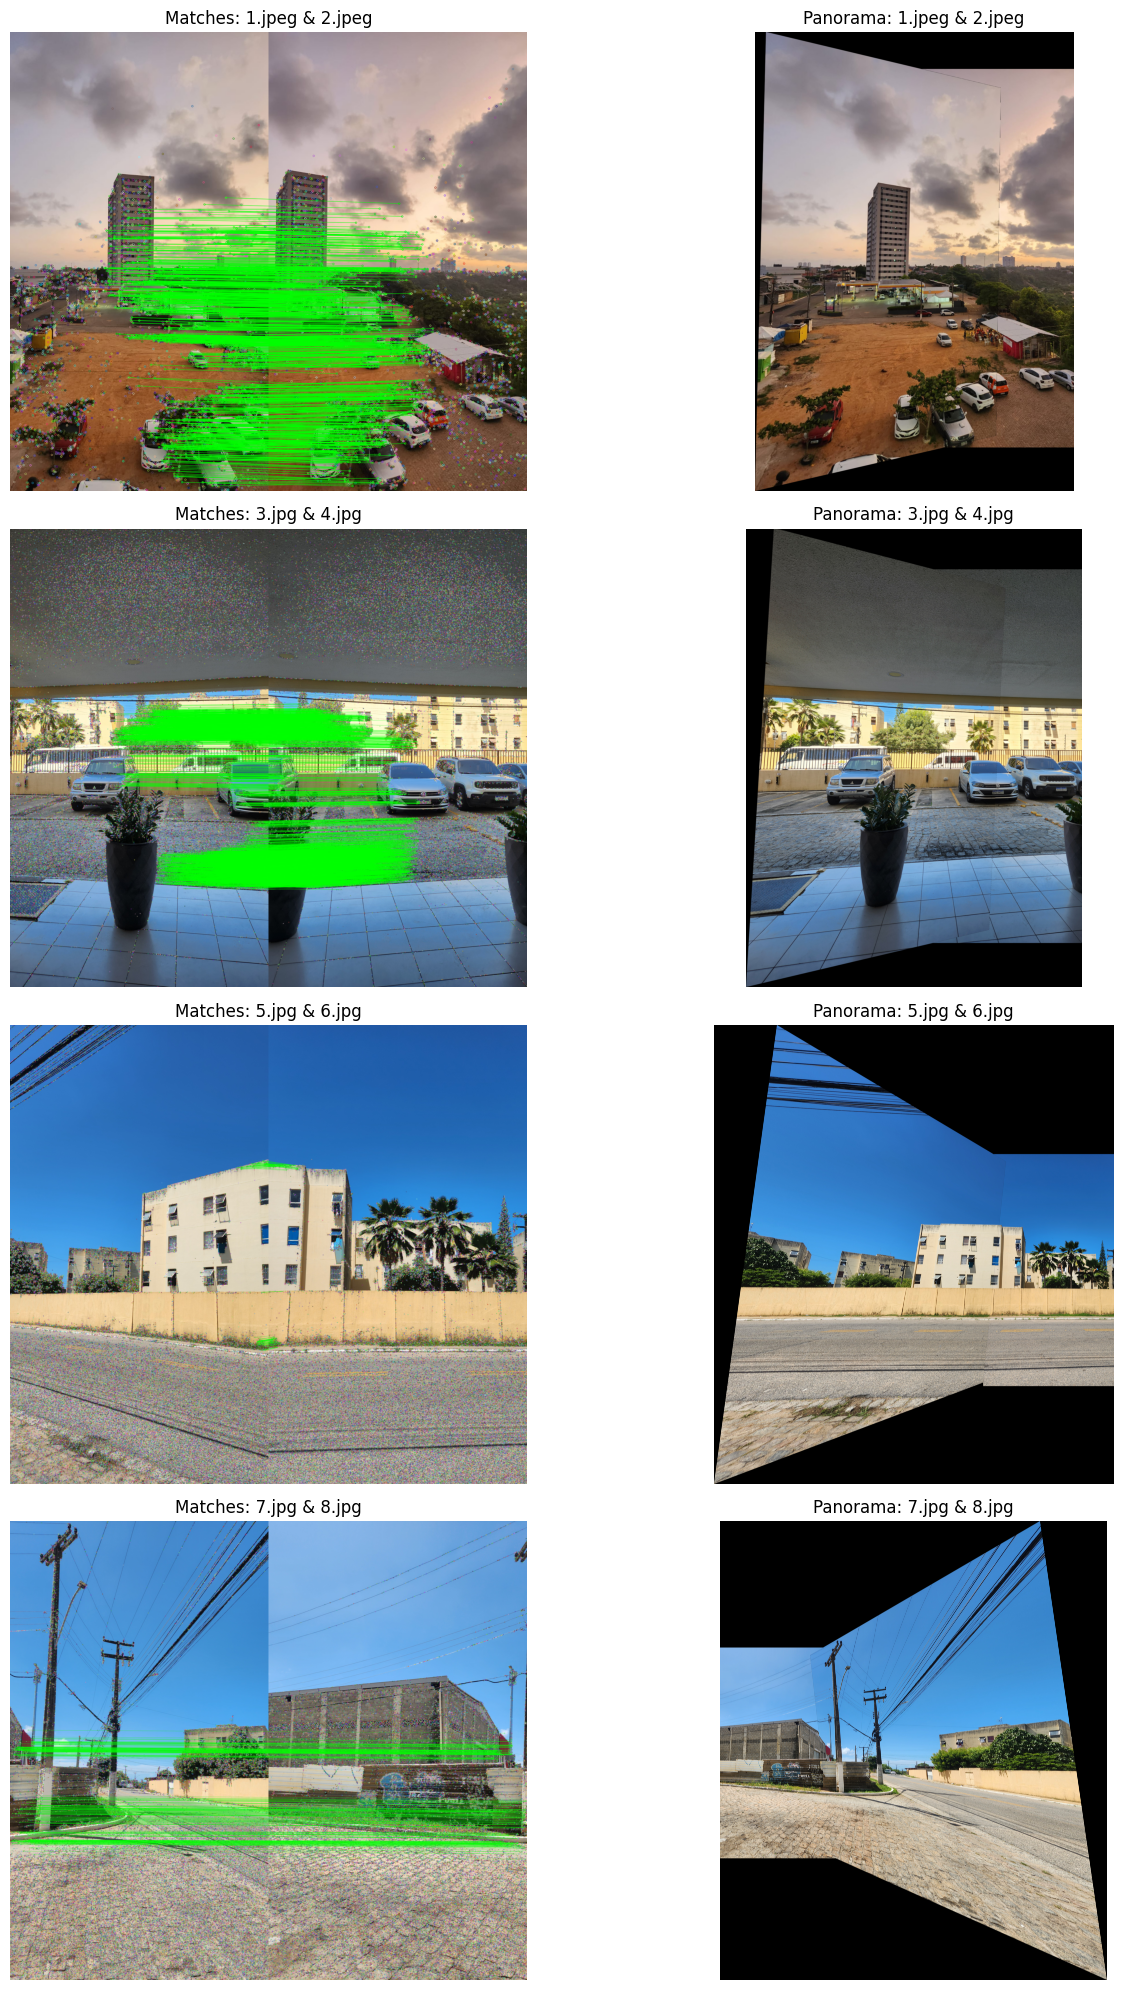

In [ ]:
# QUESTÃO I

# "panorama" de dupla de imagens, pares. Algumas funções deste foram utilizadas na task02.

def find_features_and_matches(img1, img2):
    gray1 = cv.cvtColor(img1, cv.COLOR_RGB2GRAY)
    gray2 = cv.cvtColor(img2, cv.COLOR_RGB2GRAY)
    sift = cv.SIFT_create()
    keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
    keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(descriptors1, descriptors2, k=2)
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)
    return good_matches, keypoints1, keypoints2, descriptors1, descriptors2

def compute_homography(img1, img2, show_matches=True):
    good_matches, kp1, kp2, _, _ = find_features_and_matches(img1, img2)
    if len(good_matches) < 4:
        return None, None
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    H, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
    match_visualization = None
    if show_matches:
        matchesMask = mask.ravel().tolist()
        draw_params = dict(matchColor=(0, 255, 0), singlePointColor=None, matchesMask=matchesMask, flags=cv.DrawMatchesFlags_DEFAULT)
        img1_bgr = cv.cvtColor(img1, cv.COLOR_RGB2BGR)
        img2_bgr = cv.cvtColor(img2, cv.COLOR_RGB2BGR)
        match_visualization = cv.drawMatches(img1_bgr, kp1, img2_bgr, kp2, good_matches, None, **draw_params)
        match_visualization = cv.cvtColor(match_visualization, cv.COLOR_BGR2RGB)
    return H, match_visualization

def create_panorama(img1, img2):
    H, match_visualization = compute_homography(img1, img2, show_matches=True)
    if H is None:
        print("Sem homografia.")
        return None, match_visualization

    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    corners1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    corners2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)

    corners1_transformed = cv.perspectiveTransform(corners1, H)

    all_corners = np.concatenate((corners1_transformed, corners2), axis=0)

    x_min, y_min = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    x_max, y_max = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    translation_dist = [-x_min, -y_min]
    H_translation = np.array([[1, 0, translation_dist[0]],
                              [0, 1, translation_dist[1]],
                              [0, 0, 1]], dtype=np.float32)

    panorama_width = x_max - x_min
    panorama_height = y_max - y_min

    if panorama_width <= 0 or panorama_height <= 0 or panorama_width > 10000 or panorama_height > 10000:
        print(f"W/H invalids weights: {panorama_width}x{panorama_height}. Skipping.")
        return None, match_visualization

    img2_bgr = cv.cvtColor(img2, cv.COLOR_RGB2BGR)
    panorama = cv.warpPerspective(img2_bgr, H_translation, (panorama_width, panorama_height))

    H_combined = H_translation @ H
    img1_bgr = cv.cvtColor(img1, cv.COLOR_RGB2BGR)
    warped_img1 = cv.warpPerspective(img1_bgr, H_combined, (panorama_width, panorama_height))

    mask = np.all(warped_img1 != [0, 0, 0], axis=2)
    panorama[mask] = warped_img1[mask]

    panorama_rgb = cv.cvtColor(panorama, cv.COLOR_BGR2RGB)

    return panorama_rgb, match_visualization

def process_online_image_pairs():
    images = []
    for url in URLS["q1"]["images"]:
        img = load_image_from_url(url)
        if img is not None:
            img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
            name = os.path.basename(url)
            images.append((name, img_rgb))
    
    results = []
    for i in range(1, len(images), 2):
        if i + 1 >= len(images):
            break
        img1_name, img1 = images[i - 1]
        img2_name, img2 = images[i]
        panorama, match_visualization = create_panorama(img1, img2)
        if panorama is None:
            print(f"Par não encontrado: {img1_name}, {img2_name}")
            continue
        results.append(((img1_name, img1), (img2_name, img2), panorama, match_visualization))
    return results

def display_results(results):

    num_results = len(results)
    fig, axes = plt.subplots(num_results, 2, figsize=(15, 5 * num_results))

    if num_results == 1:
        axes = np.array([axes])

    for i, ((img1_name, _), (img2_name, _), panorama, match_visualization) in enumerate(results):
        axes[i, 0].imshow(match_visualization)
        axes[i, 0].set_title(f"Matches: {img1_name} & {img2_name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(panorama)
        axes[i, 1].set_title(f"Panorama: {img1_name} & {img2_name}")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

results = process_online_image_pairs()
display_results(results)

Processando trio (0, 1, 2)
Processando trio (3, 4, 5)
Processando trio (6, 7, 8)
Processando trio (9, 10, 11)
Processando trio (12, 13, 14)
Processando trio (15, 16, 17)


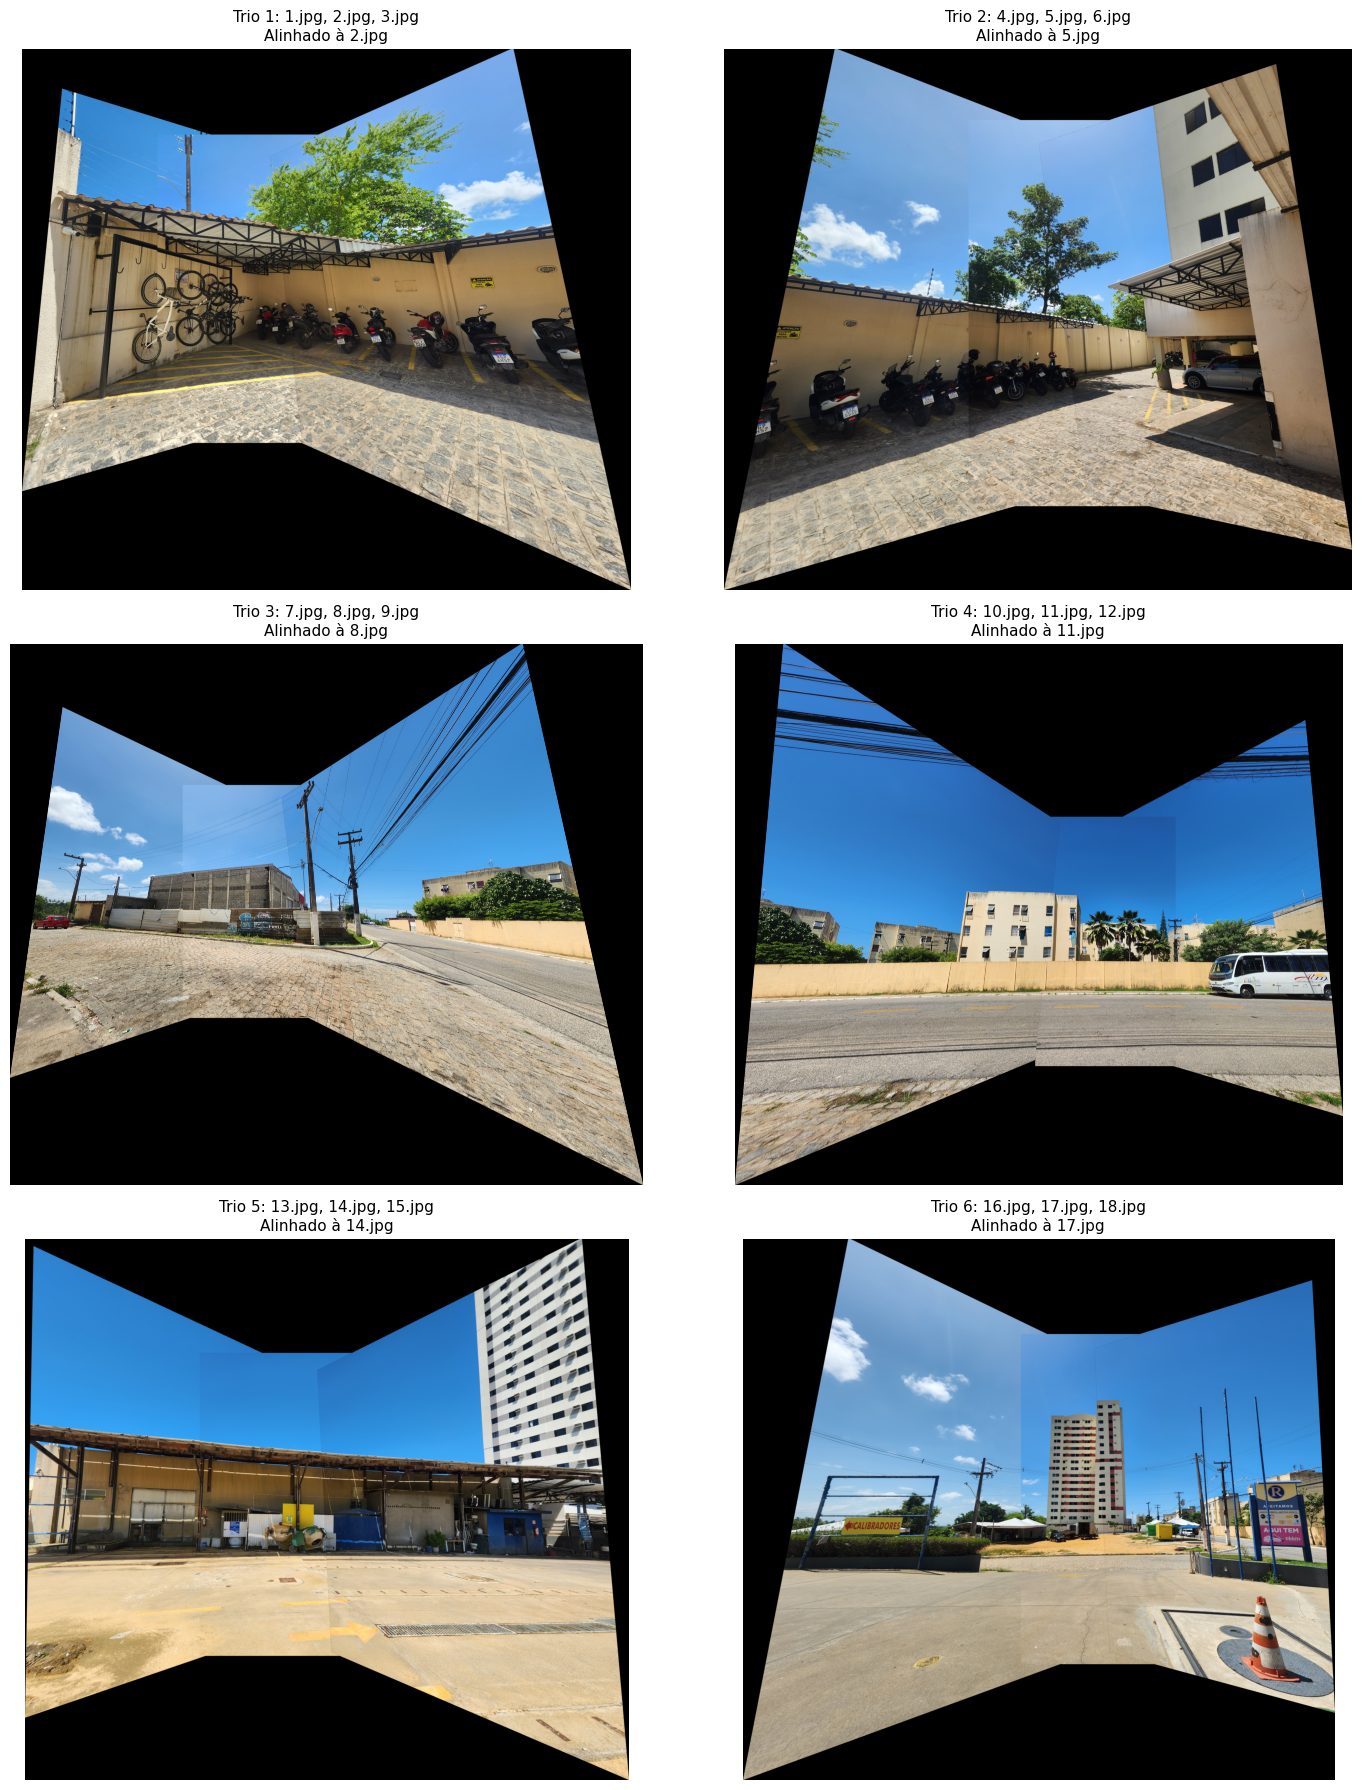

In [ ]:
# QUESTÃO II

# Panorama com trios de imagens: alinhamento por homografia.
# Da imagem 2 para 1, e da 2 para 3.

def calc_homografias_trio(img1, img2, img3):
    H12, _ = compute_homography(img1, img2, show_matches=False)
    if H12 is None:
        return None, None

    H23, _ = compute_homography(img2, img3, show_matches=False)
    if H23 is None:
        return H12, None

    return H12, H23

def compor_homografias(H12, H23, alvo_idx):
    """
    Alinha as 3 imagens ao plano da imagem do índice 'alvo_idx' (0, 1 ou 2).
    Retorna (H1_alvo, H2_alvo, H3_alvo).
    """
    I = np.identity(3, dtype=np.float32)
    H21, H32, H13, H31 = None, None, None, None

    try:
        H21 = np.linalg.inv(H12)
    except np.linalg.LinAlgError:
        if alvo_idx == 0: return None, None, None
    try:
        H32 = np.linalg.inv(H23)
    except np.linalg.LinAlgError:
        if alvo_idx in (0, 1): return None, None, None

    if H12 is not None and H23 is not None:
        H13 = H12 @ H23
    if H32 is not None and H21 is not None:
        H31 = H32 @ H21

    if alvo_idx == 0:
        if H21 is None or H31 is None:
            return None, None, None
        return I, H21, H31
    elif alvo_idx == 1:
        if H12 is None or H32 is None:
            return None, None, None
        return H12, I, H32
    elif alvo_idx == 2:
        if H13 is None or H23 is None:
            return None, None, None
        return H13, H23, I
    else:
        raise ValueError("alvo_idx deve ser 0, 1 ou 2")

def aplicar_e_juntar(img1, img2, img3, H1, H2, H3):
    """Aplica warp nas 3 imagens e junta num panorama."""
    imagens = [img1, img2, img3]
    hs = [H1, H2, H3]
    tamanhos = [img.shape[:2] for img in imagens]

    cantos_transformados = []
    for i, img in enumerate(imagens):
        h, w = tamanhos[i]
        cantos = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
        if hs[i] is not None:
            try:
                t = cv.perspectiveTransform(cantos, hs[i])
                cantos_transformados.append(t)
            except cv.error:
                pass

    if not cantos_transformados:
        return None

    todos_cantos = np.concatenate(cantos_transformados, axis=0)

    x_min, y_min = np.int32(todos_cantos.min(axis=0).ravel() - 0.5)
    x_max, y_max = np.int32(todos_cantos.max(axis=0).ravel() + 0.5)
    desloc = [-x_min, -y_min]
    H_desloc = np.array([[1, 0, desloc[0]],
                         [0, 1, desloc[1]],
                         [0, 0, 1]], dtype=np.float32)

    largura = x_max - x_min
    altura = y_max - y_min

    if largura <= 0 or altura <= 0 or largura > 15000 or altura > 15000:
        return None

    panorama = np.zeros((altura, largura, 3), dtype=np.uint8)

    for i, img in enumerate(imagens):
        if hs[i] is not None:
            H_total = H_desloc @ hs[i]
            img_bgr = cv.cvtColor(img, cv.COLOR_RGB2BGR)
            try:
                img_warp = cv.warpPerspective(img_bgr, H_total, (largura, altura),
                                              borderMode=cv.BORDER_CONSTANT, borderValue=(0, 0, 0))

                mascara = np.all(img_warp != [0, 0, 0], axis=2)
                panorama[mascara] = img_warp[mascara]
            except cv.error:
                pass

    return cv.cvtColor(panorama, cv.COLOR_BGR2RGB)

def encontrar_indices_por_nome(imagens, nomes_alvo):
    """Acha índices com base nos nomes dos arquivos."""
    indices = []
    nomes = [nome for nome, _ in imagens]

    for alvo in nomes_alvo:
        try:
            idx = nomes.index(alvo)
            indices.append(idx)
        except ValueError:
            return None

    return indices if len(indices) == len(nomes_alvo) else None

def processar_trios_sequenciais():
    """Processa trios em sequência (0,1,2), (3,4,5)..."""
    imagens = []
    for url in URLS["q2"]["images"]:
        img = load_image_from_url(url)
        if img is not None:
            img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
            nome = os.path.basename(url)
            imagens.append((nome, img_rgb))

    if len(imagens) < 3:
        print(f"São necessárias 3 imagens, foram encontradas {len(imagens)}")
        return []

    resultados = []
    limite = min(18, len(imagens))

    for i in range(0, limite - 2, 3):
        trio = (i, i + 1, i + 2)
        print(f"Processando trio {trio}")

        idx1, idx2, idx3 = trio
        nome1, img1 = imagens[idx1]
        nome2, img2 = imagens[idx2]
        nome3, img3 = imagens[idx3]

        H12, H23 = calc_homografias_trio(img1, img2, img3)
        if H12 is None or H23 is None:
            continue

        panoramas = {}
        for alvo in range(3):
            H1, H2, H3 = compor_homografias(H12, H23, alvo)
            if H1 is None or H2 is None or H3 is None:
                continue

            pano = aplicar_e_juntar(img1, img2, img3, H1, H2, H3)
            if pano is not None:
                panoramas[alvo] = pano

        if panoramas:
            resultados.append({
                'nomes': (nome1, nome2, nome3),
                'indices': trio,
                'panoramas': panoramas
            })

    return resultados

def mostrar_panorama_central(resultados):
    """Mostra panoramas alinhados à imagem central de cada trio."""
    if not resultados:
        return

    n = len(resultados)
    colunas = 2
    linhas = (n + 1) // 2

    fig, eixos = plt.subplots(linhas, colunas, figsize=(15, 6 * linhas))
    if linhas == 1:
        eixos = np.array([eixos])

    for i, res in enumerate(resultados):
        lin, col = i // colunas, i % colunas
        ax = eixos[lin, col]
        nomes = res['nomes']
        panoramas = res['panoramas']

        alvo = 1  # imagem do meio
        if alvo in panoramas:
            pano = panoramas[alvo]
            ax.imshow(pano)
            ax.set_title(f"Trio {i+1}: {nomes[0]}, {nomes[1]}, {nomes[2]}\nAlinhado à {nomes[1]}", fontsize=11)
        elif panoramas:
            alt = list(panoramas.keys())[0]
            pano = panoramas[alt]
            ax.imshow(pano)
            ax.set_title(f"Trio {i+1}: {nomes[0]}, {nomes[1]}, {nomes[2]}\nAlinhado à {nomes[alt]} (alternativo)", fontsize=11)
        else:
            ax.text(0.5, 0.5, 'Falha na criação',
                    horizontalalignment='center', verticalalignment='center',
                    transform=ax.transAxes, fontsize=12, color='red')
            ax.set_title(f"Trio {i+1}: {nomes[0]}, {nomes[1]}, {nomes[2]}\nFalha no alinhamento", fontsize=11)
        ax.axis('off')

    for i in range(len(resultados), linhas * colunas):
        lin, col = i // colunas, i % colunas
        eixos[lin, col].axis('off')

    plt.tight_layout()
    plt.show()

# Execução
resultados_q2 = processar_trios_sequenciais()
mostrar_panorama_central(resultados_q2)


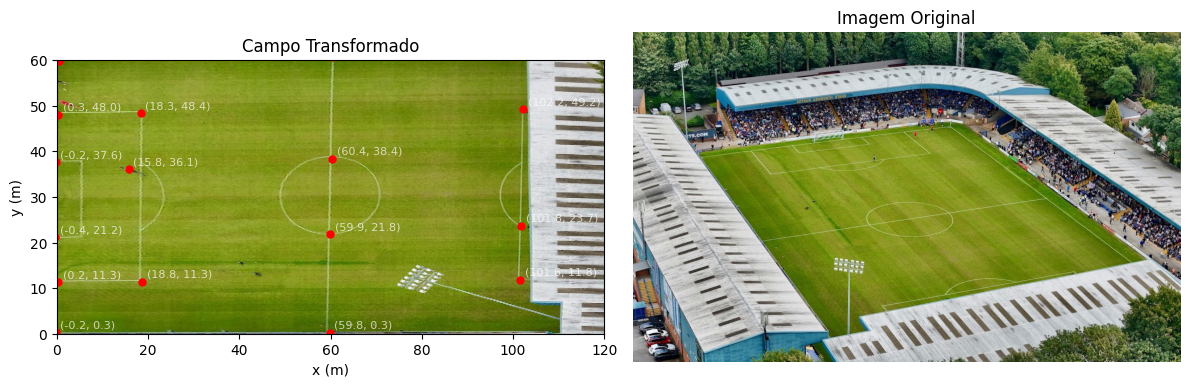

Coordenadas dos pontos em metros:
Ponto 1: (-0.22, 0.35)
Ponto 2: (0.39, 59.86)
Ponto 3: (0.24, 11.31)
Ponto 4: (0.26, 48.04)
Ponto 5: (-0.23, 37.63)
Ponto 6: (-0.37, 21.18)
Ponto 7: (18.77, 11.34)
Ponto 8: (18.35, 48.38)
Ponto 9: (59.78, 0.26)
Ponto 10: (59.92, 21.76)
Ponto 11: (60.36, 38.42)
Ponto 12: (60.40, 60.74)
Ponto 13: (101.55, 11.78)
Ponto 14: (102.22, 49.18)
Ponto 15: (101.78, 23.68)
Ponto 16: (15.75, 36.06)


In [39]:
# QUESTÃO III:
# Métodos de homografia e amarrar as métricas do campo

soccer_img = load_image_from_url(URLS["q3"]["soccer"])
soccer_img_rgb = cv.cvtColor(soccer_img, cv.COLOR_BGR2RGB)

# Ponto cantos para homografia
positions = [
    [146, 275],
    [685, 208],
    [1149, 569],
    [461, 711]
]
pts_src = np.array(positions, dtype=np.float32)
field_width, field_height = 120, 60
scale = 5

# aqui rotação do campo
pts_dst = np.array([
    [0, 0],
    [0, field_height * scale],
    [field_width * scale, field_height * scale],
    [field_width * scale, 0],
], dtype=np.float32)

H, _ = cv.findHomography(pts_src, pts_dst)
w_w, w_h = field_width * scale, field_height * scale
warped_img = cv.warpPerspective(soccer_img, H, (w_w, w_h))
warped_img_rgb = cv.cvtColor(warped_img, cv.COLOR_BGR2RGB)

#coordenadas dos pontos que quero saber em metros
positions_mapping = [
    [149, 274],
    [685, 209],
    [256, 262],
    [586, 221],
    [495, 231],
    [347, 249],
    [297, 311],
    [640, 264],
    [280, 456],
    [512, 420],
    [681, 395],
    [891, 362],
    [540, 596],
    [953, 521],
    [678, 571],
    [523, 272]
]

field_coords = []
for pt in positions_mapping:
    p_array = np.array([pt], dtype=np.float32).reshape(-1, 1, 2)
    p_trans = cv.perspectiveTransform(p_array, H)[0][0]
    # translading
    fx = p_trans[0] / scale
    fy = p_trans[1] / scale
    field_coords.append((fx, fy))

fig, (ax_trans, ax_orig) = plt.subplots(1, 2, figsize=(12, 5))

ax_trans.imshow(warped_img_rgb, extent=[0, field_width, 0, field_height], origin='lower')
for i, (fx, fy) in enumerate(field_coords, start=1):
    ax_trans.plot(fx, fy, 'ro', markersize=5)
    ax_trans.text(fx + 1, fy + 1, f"({fx:.1f}, {fy:.1f})",
                  color='white', fontsize=8, alpha=0.7)

ax_trans.set_xlim(0, field_width)
ax_trans.set_ylim(0, field_height)
ax_trans.set_xlabel("x (m)")
ax_trans.set_ylabel("y (m)")
ax_trans.set_title("Campo Transformado")

ax_orig.imshow(soccer_img_rgb)
ax_orig.set_title("Imagem Original")
ax_orig.axis("off")

plt.tight_layout()
plt.show()

print("Coordenadas dos pontos em metros:")
for i, (x, y) in enumerate(field_coords, start=1):
    print(f"Ponto {i}: ({x:.2f}, {y:.2f})")

Calibração concluída com 3 imagens
Matriz da câmera (mtx):
[[3.05667963e+03 0.00000000e+00 1.00993159e+03]
 [0.00000000e+00 2.93188868e+03 1.06438845e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Coeficientes de distorção (dist):
[[ 2.78546326e-01 -1.09375264e+01 -5.79199668e-04  4.55087458e-04
   7.40164797e+01]]


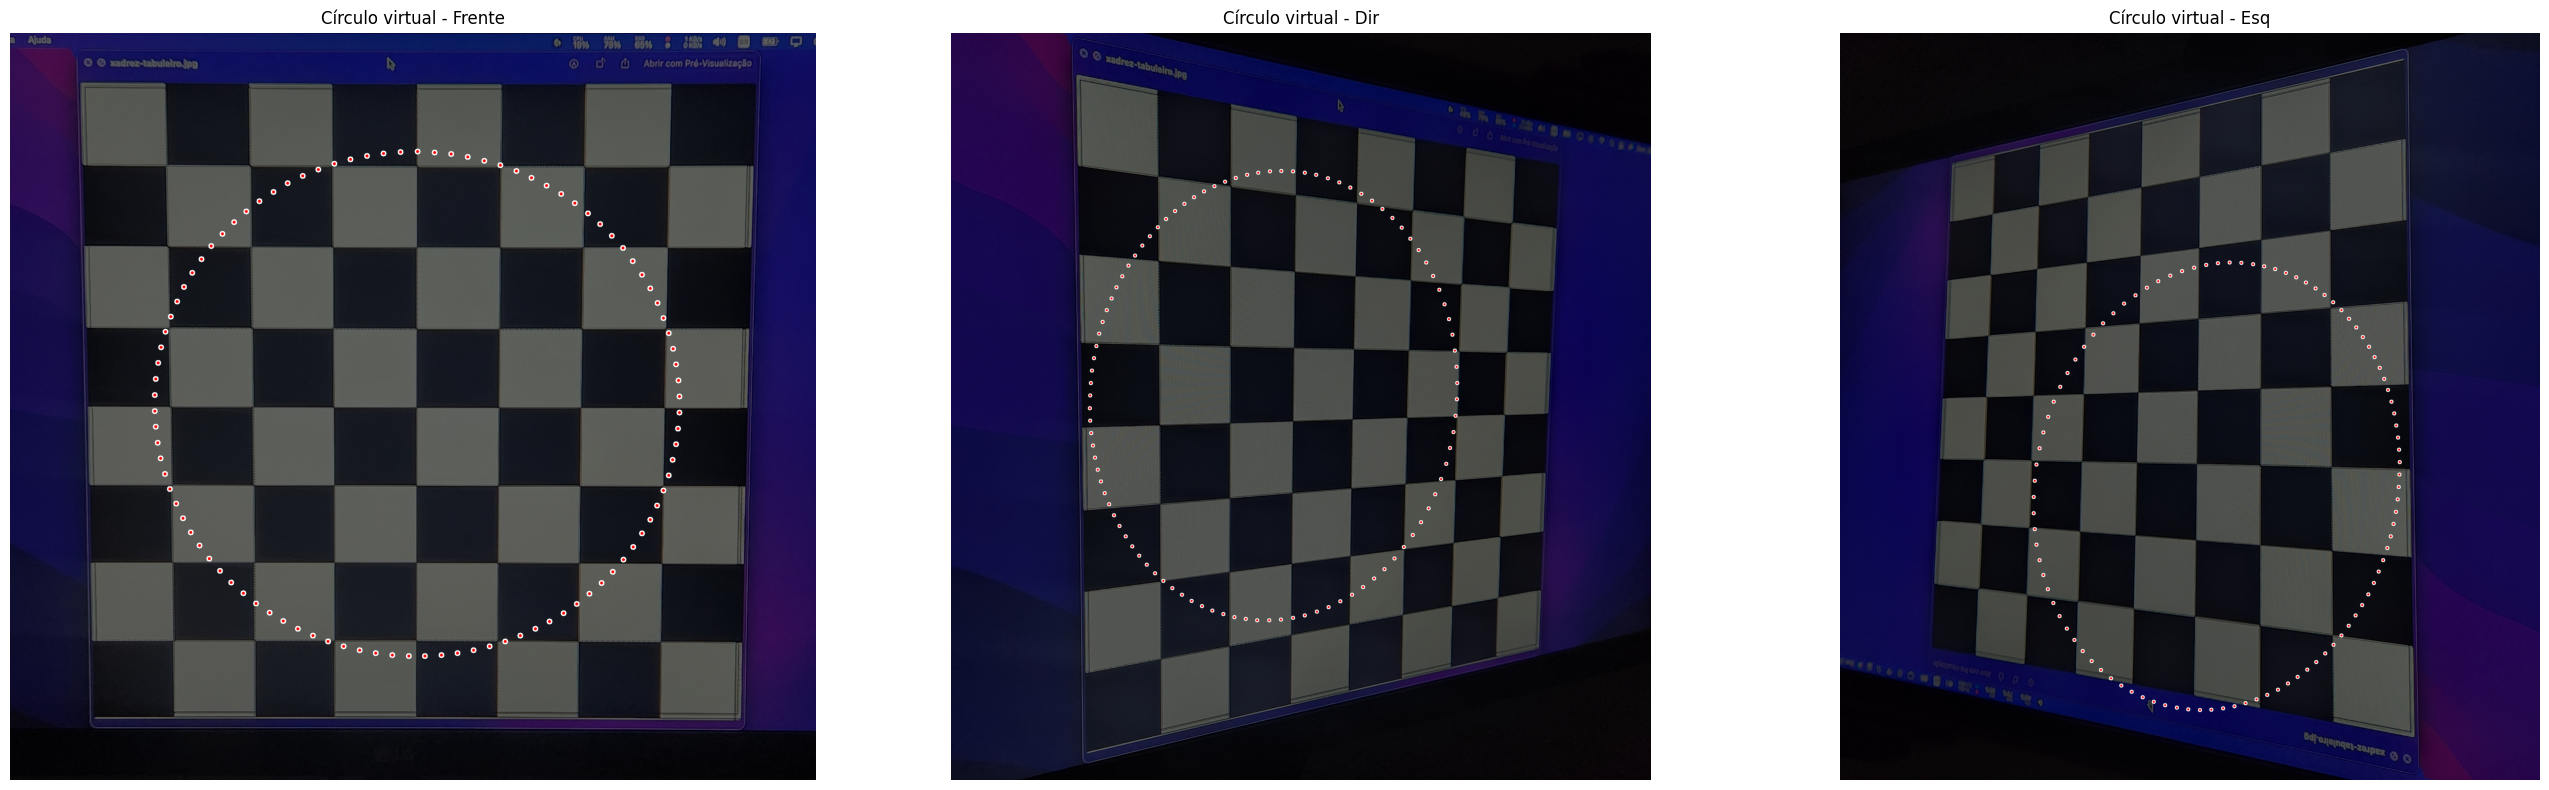

Professor, eu estava tendo problemas com a imagem do lado direito, então tive a ideia de inverter a imagem lado direito para lado esquerdo. 
Mas Acho que ainda sim cumpre o propósito de identificar sua direção


In [40]:
# QUESTÃO II
# Calibração da câmera e projeção de um círculo em 3 imagens do tabuleiro de xadrez

# Params do tabuleiro
square_size = 3.5  # cm por quadrado
W = 8 * square_size #tamanho do tabuleiro
H = 8 * square_size #tamanho do tabuleiro
r = 0.4 * min(W, H) # só pra controle do tamanho do círculo

imgs_calibration = []
gray_images = []

for key in ["frente", "esq", "dir"]:
    img = load_image_from_url(URLS["q4"][key])
    if img is not None:
        imgs_calibration.append(img)
        gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        gray_images.append(gray)

# critérios de max iterations
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ajuste para pontos internos (7x7 quadrados)
objp = np.zeros((6*6, 3), np.float32)
objp[:, :2] = np.mgrid[0:6, 0:6].T.reshape(-1, 2) * square_size

# Array storage
objpoints = []  # pontos 3D no espaço real
imgpoints = []  # pontos 2D no plano da imagem

# Processar cada imagem
for i, gray in enumerate(gray_images):
    # Encontra os cantos do tabuleiro
    ret, corners = cv.findChessboardCorners(gray, (6, 6), None)
    
    if ret:
        objpoints.append(objp)
        
        # Coordenadas dos cantos
        corners2 = cv.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        imgpoints.append(corners2)
        
        # Debug rapidao pra visualizar cantos detectados
        #img_display = imgs_calibration[i].copy()
        #cv.drawChessboardCorners(img_display, (6, 6), corners2, ret)
        #plt.figure(figsize=(8, 6))
        #plt.imshow(cv.cvtColor(img_display, cv.COLOR_BGR2RGB))
        #plt.title(f"Cantos do tabuleiro - Imagem {i+1}")
        #plt.axis('off')
        #plt.show()

# Realizar calibração da câmera se tiver pontos suficientes
if len(objpoints) > 0:
    ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(
        objpoints, imgpoints, gray_images[0].shape[::-1], None, None
    )
    print(f"Calibração concluída com {len(objpoints)} imagens")
    print(f"Matriz da câmera (mtx):\n{mtx}")
    print(f"Coeficientes de distorção (dist):\n{dist}")

# Melhor centralização no meio do tabuleiro (em vez de 0.5*W)
tabuleiro_centro = np.array([3 * square_size, 3 * square_size])  # centro do 6x6

# Pontos 3D do círculo (z=0 porque está no plano do tabuleiro)
theta = np.linspace(0, 2 * np.pi, 100)
circle_3d = np.array([
    [r * np.cos(t) + tabuleiro_centro[0], r * np.sin(t) + tabuleiro_centro[1], 0]
    for t in theta
], dtype=np.float32)

views = []
if len(rvecs) >= 1 and len(tvecs) >= 1:
    views.append(("Frente", rvecs[0], tvecs[0]))
if len(rvecs) >= 2 and len(tvecs) >= 2:
    views.append(("Dir", rvecs[1], tvecs[1]))
if len(rvecs) >= 3 and len(tvecs) >= 3:
    views.append(("Esq", rvecs[2], tvecs[2]))

# plots
fig, axes = plt.subplots(1, len(views), figsize=(9 * len(views), 8))
if len(views) == 1:
    axes = [axes]

for i, (title, rvec, tvec) in enumerate(views):
    key = title.lower()
    if key not in URLS["q4"]:
        print(f"Imagem '{title}' não encontrada nos URLs.")
        continue
    img_copy = load_image_from_url(URLS["q4"][key])
    if img_copy is None:
        continue

  # escurece a imagem pra projetar melhor o circulo
    img_dark = (img_copy * 0.4).astype(np.uint8)
    circle_2d, _ = cv.projectPoints(circle_3d, rvec, tvec, mtx, dist)

    for point in circle_2d:
        x, y = point.ravel()
        x, y = int(round(x)), int(round(y))
        if 0 <= x < img_copy.shape[1] and 0 <= y < img_copy.shape[0]:
            cv.circle(img_dark, (x, y), 6, (255, 255, 255), -1)
            cv.circle(img_dark, (x, y), 3, (0, 0, 255), -1)

    axes[i].imshow(cv.cvtColor(img_dark, cv.COLOR_BGR2RGB))
    axes[i].set_title(f"Círculo virtual - {title}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

print("Professor, eu estava tendo problemas com a imagem do lado direito, então tive a ideia de inverter a imagem lado direito para lado esquerdo. \nMas Acho que ainda sim cumpre o propósito de identificar sua direção")